<a href="https://colab.research.google.com/github/mmadhumitha-22/Birru-Madhumitha/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     Customer Name     Sales     Profit  Quantity    Region  Category
0    Aaron Bergman   886.156   129.3465        13       1.5  0.833333
1    Aaron Hawkins  1744.700   365.2152        54       2.0       1.0
2   Aaron Smayling  3050.692  -253.5746        48       1.8       1.0
3  Adam Bellavance  7755.620  2054.5885        56  1.555556       1.0
4        Adam Hart  3250.337   281.1890        75      1.55      0.75


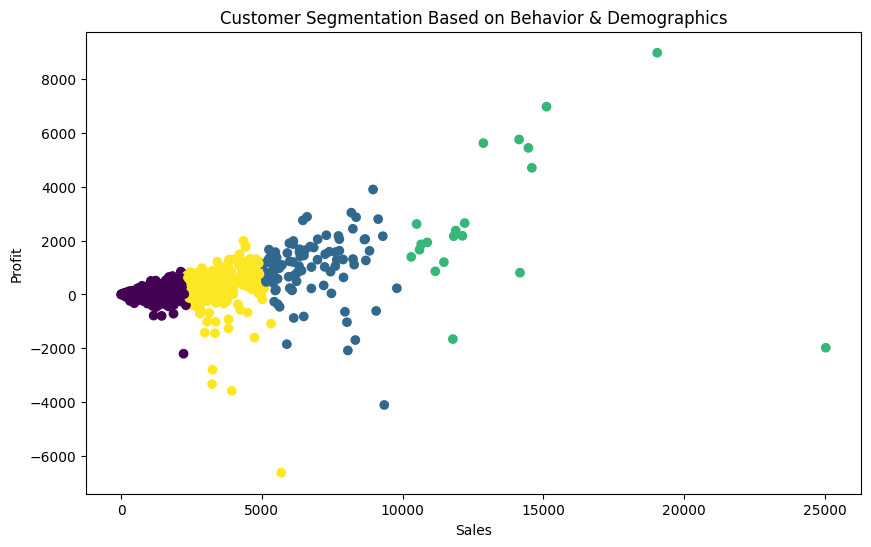


========== CLUSTER SUMMARY ==========
                Sales       Profit   Quantity    Region  Category
Cluster                                                          
0         1148.633828   110.611669  33.544304  1.544867  0.948933
1         6730.377768   994.055576  73.537634  1.631311  1.013358
2        13245.483350  2776.800820  73.450000  1.436077  0.979103
3         3342.651575   332.358693  57.245614  1.587979   0.97263

Customer Segmentation Project Completed Successfully!


In [9]:
# ==========================================
# CUSTOMER SEGMENTATION PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# ==========================================
# DATA PREPROCESSING
# ==========================================

# Remove missing values
df.dropna(inplace=True)

# Select useful columns
data = df[['Customer Name', 'Sales', 'Profit',
           'Quantity', 'Region', 'Category']].copy()

# Encode categorical columns
le_region = LabelEncoder()
le_category = LabelEncoder()

data.loc[:, 'Region'] = le_region.fit_transform(data['Region'])
data.loc[:, 'Category'] = le_category.fit_transform(data['Category'])

# Group customer behavior
customer_data = data.groupby('Customer Name').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum',
    'Region':'mean',
    'Category':'mean'
}).reset_index()

print(customer_data.head())

# ==========================================
# FEATURE SELECTION
# ==========================================

X = customer_data[['Sales', 'Profit',
                   'Quantity', 'Region', 'Category']]

# ==========================================
# APPLY K-MEANS CLUSTERING
# ==========================================

kmeans = KMeans(n_clusters=4, random_state=42)

customer_data['Cluster'] = kmeans.fit_predict(X)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    customer_data['Sales'],
    customer_data['Profit'],
    c=customer_data['Cluster']
)

plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Customer Segmentation Based on Behavior & Demographics')

plt.show()

# ==========================================
# CLUSTER SUMMARY
# ==========================================

cluster_summary = customer_data.groupby('Cluster')[['Sales', 'Profit', 'Quantity', 'Region', 'Category']].mean()

print("\n========== CLUSTER SUMMARY ==========")
print(cluster_summary)

# ==========================================
# SAVE OUTPUT
# ==========================================

customer_data.to_csv('customer_segments.csv', index=False)

print("\nCustomer Segmentation Project Completed Successfully!")